<a href="https://colab.research.google.com/github/renuka2929-tech/LP5-Practicals/blob/main/DL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Data: 25000
Testing Data: 25000
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7146 - loss: 0.5147 - val_accuracy: 0.8544 - val_loss: 0.3323
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9323 - loss: 0.1797 - val_accuracy: 0.8596 - val_loss: 0.3301
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9893 - loss: 0.0483 - val_accuracy: 0.8662 - val_loss: 0.3577
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9983 - loss: 0.0112 - val_accuracy: 0.8524 - val_loss: 0.4330
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9995 - loss: 0.0048 - val_accuracy: 0.8578 - val_loss: 0.4451
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8556 - loss: 0.4648

Test Accuracy: 0.8555600047111511
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Sample Predictions:

Actual: Negative | Predicted: Negative
Actual: Positive | Predicted: Positive
Actual: Positive | Predicted: Positive
Actual: Negative | Predicted: Negative
Actual: Positive | Predicted: Positive
Ac

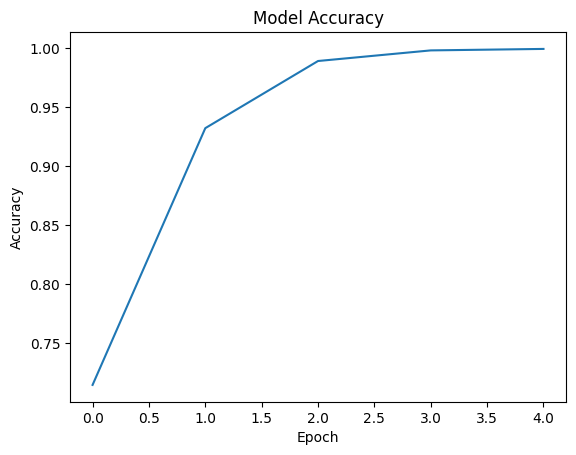


Model Saved Successfully


In [1]:
# ============================================
# Binary Classification using Deep Neural Network
# IMDB Movie Review Sentiment Analysis
# ============================================

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================
# Load IMDB Dataset
# ============================================

# Keep only top 10000 most common words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# ============================================
# Display Dataset Information
# ============================================
print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

# ============================================
# Padding Sequences
# ============================================

max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

# ============================================
# Create Deep Neural Network
# ============================================

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=max_length
    )
)

# Flatten Layer
model.add(Flatten())

# Hidden Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# ============================================
# Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ============================================
# Train Model
# ============================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# ============================================
# Evaluate Model
# ============================================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# ============================================
# Predictions
# ============================================

predictions = model.predict(X_test)

print("\nSample Predictions:\n")

for i in range(10):

    predicted = "Positive" if predictions[i] > 0.5 else "Negative"

    actual = "Positive" if y_test[i] == 1 else "Negative"

    print(
        "Actual:", actual,
        "| Predicted:", predicted
    )

# ============================================
# Accuracy Graph
# ============================================

plt.plot(history.history['accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

# ============================================
# Save Model
# ============================================

model.save("imdb_sentiment_model.h5")

print("\nModel Saved Successfully")